In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

df = pd.read_csv(r'F:\Study\4th Sem\INT375 (PY)\Project\real time AQI from various placs.csv')
df.head(10)

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",23-02-2026 10:00,13.670000,79.350000,NH3,1.0,2.0,1.0
1,India,Andhra_Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",23-02-2026 10:00,13.670000,79.350000,CO,1.0,41.0,9.0
2,India,Andhra_Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",23-02-2026 10:00,13.670000,79.350000,OZONE,9.0,38.0,13.0
3,India,Andhra_Pradesh,Tirupati,"Vaikuntapuram, Tirupati - APPCB",23-02-2026 10:00,13.615387,79.409230,PM2.5,59.0,114.0,79.0
4,India,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",23-02-2026 10:00,16.536107,80.594233,NO2,17.0,17.0,17.0
5,India,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",23-02-2026 10:00,16.536107,80.594233,CO,34.0,35.0,34.0
6,India,Andhra_Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",23-02-2026 10:00,16.509717,80.612222,NH3,NaN,NaN,NaN
7,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",23-02-2026 10:00,25.265194,87.012947,OZONE,13.0,37.0,15.0
8,India,Bihar,Bihar Sharif,"D M Colony, Bihar Sharif - BSPCB",23-02-2026 10:00,25.204762,85.514960,PM2.5,30.0,85.0,50.0
9,India,Bihar,Bihar Sharif,"D M Colony, Bihar Sharif - BSPCB",23-02-2026 10:00,25.204762,85.514960,NO2,9.0,10.0,10.0


In [2]:
#shape and datatypes of the dataset
print(df.shape)
print()
print(df.info())
print()
print(df.dtypes)


(3207, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3207 non-null   object 
 1   state          3207 non-null   object 
 2   city           3207 non-null   object 
 3   station        3207 non-null   object 
 4   last_update    3207 non-null   object 
 5   latitude       3207 non-null   float64
 6   longitude      3207 non-null   float64
 7   pollutant_id   3207 non-null   object 
 8   pollutant_min  3044 non-null   float64
 9   pollutant_max  3044 non-null   float64
 10  pollutant_avg  3044 non-null   float64
dtypes: float64(5), object(6)
memory usage: 275.7+ KB
None

country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64

In [3]:
#checking for null values
print(df.isnull().sum())
print()
print(df[df['pollutant_avg'].isna()]['pollutant_id'].value_counts())
print()
#check for duplicates
print(df.duplicated().sum())



country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    163
pollutant_max    163
pollutant_avg    163
dtype: int64

pollutant_id
SO2      31
NO2      30
PM2.5    30
PM10     28
NH3      22
OZONE    11
CO       11
Name: count, dtype: int64

0


In [4]:
#categorical exploration
df['state'].unique()

array(['Andhra_Pradesh', 'Bihar', 'Arunachal_Pradesh', 'Assam',
       'Chhattisgarh', 'Delhi', 'Chandigarh', 'Gujarat', 'Haryana',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Jammu_and_Kashmir',
       'Maharashtra', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan',
       'Sikkim', 'TamilNadu', 'Telangana', 'Uttar_Pradesh', 'Tripura',
       'Uttarakhand', 'West_Bengal', 'Himachal Pradesh', 'Jharkhand',
       'Meghalaya', 'Mizoram', 'Nagaland'], dtype=object)

In [5]:
#data claening
#df.drop(columns=['country'], inplace=True) #dropped the country column as all the values are same
df['state'] = df['state'].str.replace('_', ' ').str.strip().str.title()
#str.strip - removes any space at the beginning and end of the string
#str.title - converts the first letter of each word to uppercase and the rest to lowercase


In [6]:
df['last_update'] = pd.to_datetime(df['last_update'], format='%d-%m-%Y %H:%M') #converting the last_update column to datetime format, earlier which was an object column
df['last_update'].dtype

dtype('<M8[ns]')

In [7]:
df['reading_available'] = df['pollutant_avg'].notna()  #163 rows had no pollutant readings (sensor offline). Instead of dropping those rows and losing the station metadata, we keep them and flag them.
#Result: True for 3,044 rows (have readings), False for 163 rows (sensor offline).

In [8]:
df['spread'] = df['pollutant_max'] - df['pollutant_min']

In [9]:
mask = (df['pollutant_avg'].notna() &
        df['pollutant_min'].notna() &
        (df['pollutant_avg'] < df['pollutant_min']))

df.loc[mask, ['pollutant_avg','pollutant_min','pollutant_max']] = float('nan')
df.loc[mask, 'reading_available'] = False
#It finds invalid rows where the average is impossibly lower than the minimum, deletes those faulty pollutant values by setting them to `NaN`, and marks the reading as unavailable (`False`).

In [10]:
df.dropna(subset=['pollutant_min', 'pollutant_max', 'pollutant_avg'], inplace=True)# dropped rows where any of the pollutant readings are missing, as they are essential for analysis. This results in a cleaner dataset with 3,044 valid rows for analysis.
df.drop(columns=['reading_available'], inplace=True) #dropped the reading_available column as it is no longer needed after dropping rows with missing pollutant readings.

In [11]:
df.to_csv("aqi_cleaned.csv", index=False)

In [12]:
#eda after cleaning
print(df.describe())
print()
print(df.shape)
print()
print(df.info())
print()
print(df.dtypes)
print()
print("null values: ",df.isnull().sum())
print()
print(df[df['pollutant_avg'].isna()]['pollutant_id'].value_counts())
print()
#check for duplicates
print(df.duplicated().sum())

                         last_update     latitude    longitude  pollutant_min  \
count                           3043  3043.000000  3043.000000    3043.000000   
mean   2026-02-23 10:00:00.000000256    23.397703    78.542872      26.211305   
min              2026-02-23 10:00:00     8.514909    70.776774       1.000000   
25%              2026-02-23 10:00:00    19.296481    75.386577       6.000000   
50%              2026-02-23 10:00:00    23.838586    77.287209      15.000000   
75%              2026-02-23 10:00:00    27.571409    80.674273      39.000000   
max              2026-02-23 10:00:00    34.063130    94.636574     266.000000   
std                              NaN     4.929658     4.906552      27.866635   

       pollutant_max  pollutant_avg       spread  
count    3043.000000    3043.000000  3043.000000  
mean       88.348998      49.344726    62.137693  
min         1.000000       1.000000     0.000000  
25%        18.000000      11.000000     6.000000  
50%        59.0

C:\Users\RELIANCE DIGITAL\AppData\Local\Temp\ipykernel_368\2326294409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities_pm25.values, y=top_cities_pm25.index, palette='Reds_r')


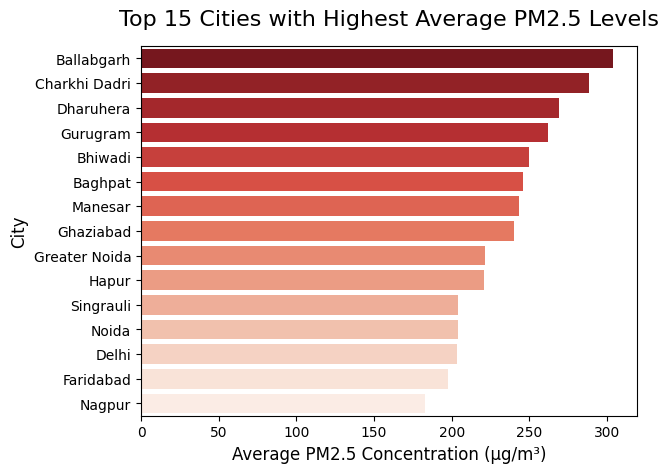

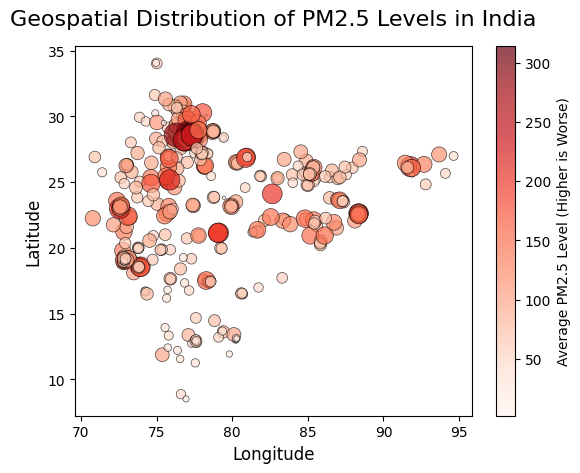

C:\Users\RELIANCE DIGITAL\AppData\Local\Temp\ipykernel_368\2326294409.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_pm25.values, y=state_pm25.index, palette='Reds_r')


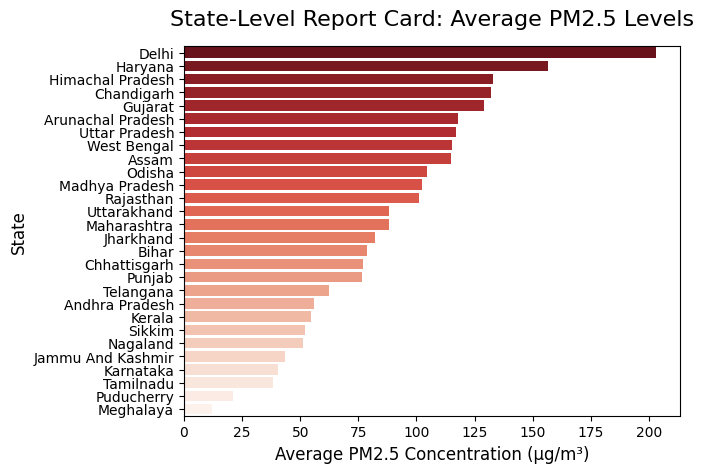

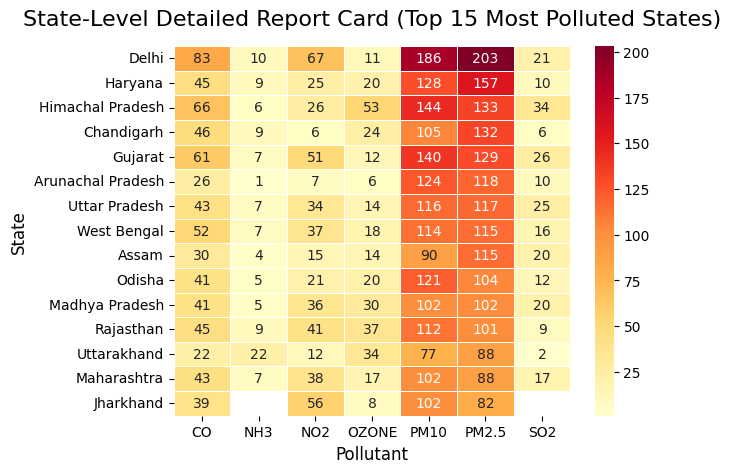

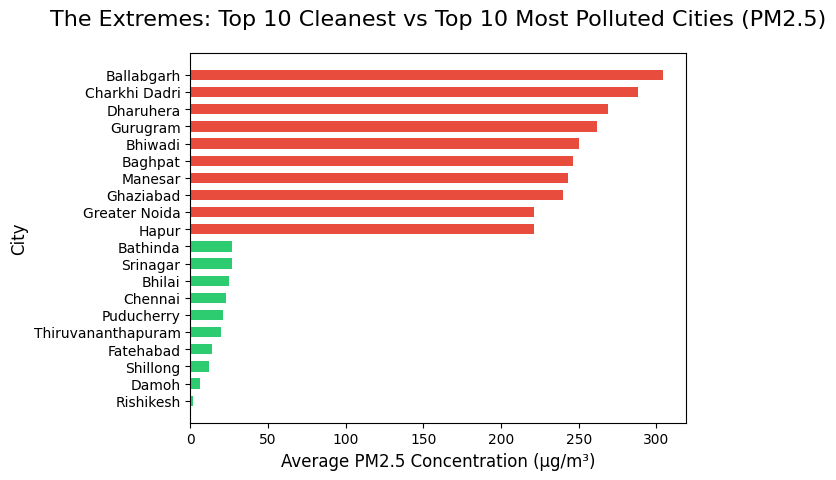

C:\Users\RELIANCE DIGITAL\AppData\Local\Temp\ipykernel_368\2326294409.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pollutant_id', y='pollutant_avg', palette='Set2')


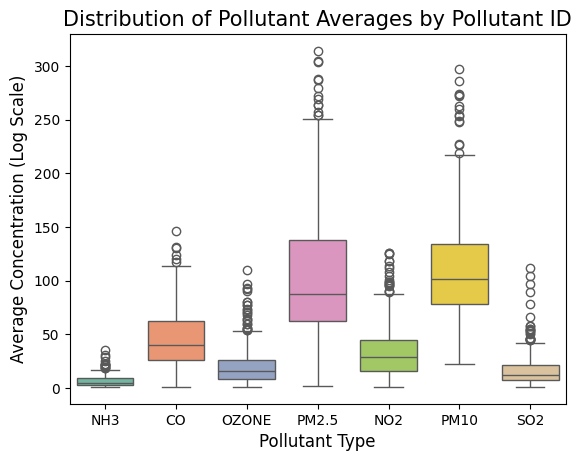

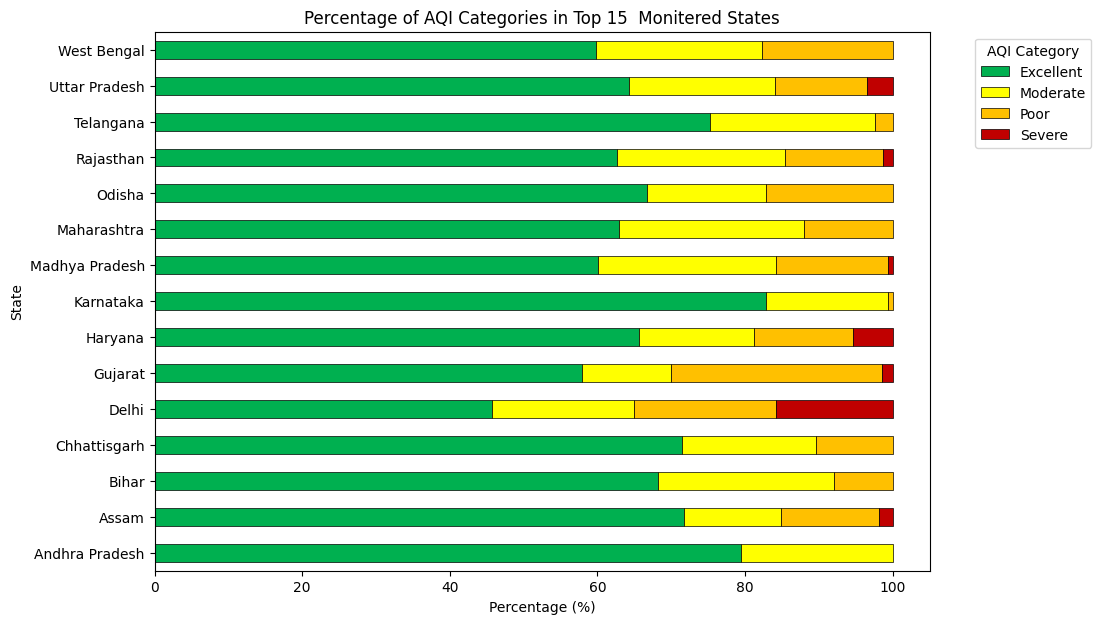

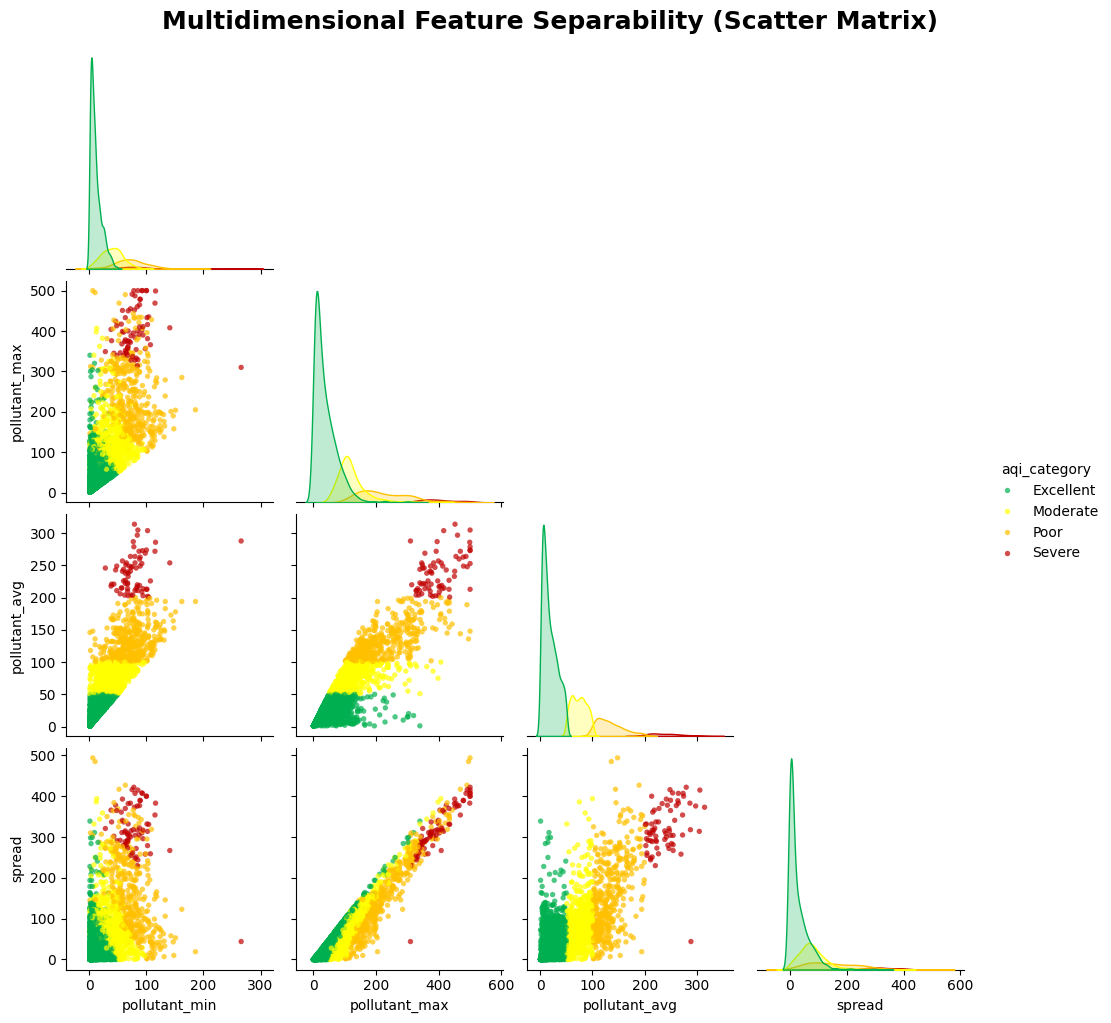

In [ ]:
#visualisations
#1 "Top 15 Cities with Highest Average PM2.5"
pm25_df = df[df['pollutant_id'] == 'PM2.5']
top_cities_pm25 = pm25_df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(15) #Calculate the average PM2.5 for each city
# We group by city, calculate the mean, sort them from highest to lowest, and grab the top 15
sns.barplot(x=top_cities_pm25.values, y=top_cities_pm25.index, palette='Reds_r')
plt.title('Top 15 Cities with Highest Average PM2.5 Levels', fontsize=16, pad=15)
plt.xlabel('Average PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

#2. geospatial map -just by plotting the longitude and latitude coordinates on a standard scatter plot, the shape of India naturally appears!
scatter = plt.scatter(
    x=pm25_df['longitude'], 
    y=pm25_df['latitude'],
    c=pm25_df['pollutant_avg'],      # Color the dots based on the pollution level
    cmap='Reds',                     # Use a color palette from Light Red to Dark Red
    s=pm25_df['pollutant_avg'],      # Make the size of the dot bigger if pollution is higher
    alpha=0.7,                       # Make dots slightly transparent so we can see overlapping stations
    edgecolors='black',              # Add a thin black border to make dots pop
    linewidth=0.5
)
plt.colorbar(scatter, label='Average PM2.5 Level (Higher is Worse)') #color bar on the side to show what the colors mean
plt.title('Geospatial Distribution of PM2.5 Levels in India', fontsize=16, pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.show()

#3. every state from worst to best based purely on PM2.5.
state_pm25 = pm25_df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False)
sns.barplot(x=state_pm25.values, y=state_pm25.index, palette='Reds_r')
plt.title('State-Level Report Card: Average PM2.5 Levels', fontsize=16, pad=15)
plt.xlabel('Average PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.show()

#4. the top 15 worst states and shows their grades across all pollutants
top_states = state_pm25.head(15).index
state_pollutants = df[df['state'].isin(top_states)].groupby(['state', 'pollutant_id'])['pollutant_avg'].mean().unstack() #We filter the dataset to include only the top 15 most polluted states, then group by state and pollutant type, calculate the average for each pollutant, and reshape the data so that each pollutant becomes a separate column.
state_pollutants = state_pollutants.loc[top_states] #reorder the states in the same order as the previous plot
sns.heatmap(state_pollutants, annot=True, cmap='YlOrRd', fmt=".0f", linewidths=.5)
plt.title('State-Level Detailed Report Card (Top 15 Most Polluted States)', fontsize=16, pad=15)
plt.xlabel('Pollutant', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.show()

#5. eextremes

city_pm25 = pm25_df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False)
top_10_worst = city_pm25.head(10)
top_10_best = city_pm25.tail(10)
combined = pd.concat([top_10_worst, top_10_best]).sort_values()
colors = ['#2ECC71' if x in top_10_best.index else '#E74C3C' for x in combined.index] #green for best, red for worst
plt.barh(combined.index, combined.values, color=colors, height=0.6)
plt.title('The Extremes: Top 10 Cleanest vs Top 10 Most Polluted Cities (PM2.5)', fontsize=16, pad=20)
plt.xlabel('Average PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

#6. We use a boxplot to show the median, quartiles, and outliers for each pollutant
sns.boxplot(data=df, x='pollutant_id', y='pollutant_avg', palette='Set2')
plt.title('Distribution of Pollutant Averages by Pollutant ID', fontsize=15)
plt.xlabel('Pollutant Type', fontsize=12)
plt.ylabel('Average Concentration (Log Scale)', fontsize=12)
plt.show()

#7. stacked horizontal bar chart illustrates the proportional breakdown of Air Quality Index (AQI) categories across the top 15 most monitored states.
top_15_states = df['state'].value_counts().head(15).index #Filter data to only include the top 15 most monitored states
df_top = df[df['state'].isin(top_15_states)]
chart_data = pd.crosstab(df_top['state'], df_top['aqi_category'], normalize='index') * 100 #Calculate the percentage of each AQI category within each state
aqi_order = ['Excellent', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
available_aqi = [aqi for aqi in aqi_order if aqi in chart_data.columns]
chart_data = chart_data[available_aqi]
color_map = { #Define the specific colors for these categories
    'Excellent': '#00b050',     # Dark Green
    'Satisfactory': '#92d050',  # Light Green
    'Moderate': '#ffff00',      # Yellow
    'Poor': '#ffc000',          # Orange
    'Very Poor': '#ff0000',     # Red
    'Severe': '#c00000'         # Dark Red
}
plot_colors = [color_map[col] for col in chart_data.columns] # Create a list of colors in the exact order of our columns
chart_data.plot(kind='barh', stacked=True, figsize=(10, 7), color=plot_colors, edgecolor='black', linewidth=0.5) # 6. Create the stacked horizontal bar chart using our custom `color` list
plt.title('Percentage of AQI Categories in Top 15  Monitered States')
plt.xlabel('Percentage (%)')
plt.ylabel('State')
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#8. multidimensional scatter matrix evaluates the statistical distributions and correlations of all numerical features, demonstrating their strong class separability and readiness for machine learning classification."
cols = ['pollutant_min', 'pollutant_max', 'pollutant_avg', 'spread', 'aqi_category'] #nly the numerical columns we want to compare, plus the category for coloring
df_pair = df[cols].copy()
present_cats = [c for c in color_map.keys() if c in df_pair['aqi_category'].unique()] #we only pass colors for categories that actually exist in the data to avoid errors
palette = {c: color_map[c] for c in present_cats}
g = sns.pairplot(df_pair, hue="aqi_category", palette=palette, corner=True, 
                 plot_kws={'alpha': 0.7, 'edgecolor': 'none', 's': 15})
g.figure.suptitle("Multidimensional Feature Separability (Scatter Matrix)", y=1.02, fontsize=18, fontweight='bold')
plt.show()

#we used pm2.5 mosstly beacuse it drives the overall aqi and is a reliable warning source that other pollutants are also high.


In [14]:
# if the dependent varaible is continuous, we can use regression models to predict pollution levels based on station metadata and temporal factors.
# If we categorize pollution levels into discrete classes (e.g., Good, Moderate, Unhealthy), we can use classification models to predict the category based on the same features.
# we have to make a ml model \
# feature selection meathod, ie vars having high importance, eg correlation can be a factor to deteremine the variables to be included in the model. 
# multi colearity
# scaling - always perfrom scaling after splitting the data set into training and testing sets to prevent data leakage.
#regression - maee, mse, r2 score
#classification - accuracy, precision, recall, f1 score, confusion matrix

In [15]:
#adding a column for AQI category based on pollutant_avg so that we can use it for ml model.

def categorize_aqi(aqi):
    if aqi <= 50:
        return "Excellent"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    else:
        return "Severe"

df['aqi_category'] = df['pollutant_avg'].apply(categorize_aqi)

df['aqi_category'] = df['pollutant_avg'].apply(categorize_aqi)
print(df['aqi_category'].value_counts())

aqi_category
Excellent    1963
Moderate      631
Poor          379
Severe         70
Name: count, dtype: int64


In [17]:
#ML model to predict aqi category based on input like location, ppollutant type and time
#the model will learn patterns from the data to predict the AQI category for new, unseen data based on the features provided
#a Random Forest Classification model that predicts Air Quality categories based on environmental and geographic features. (supervised learning -> classification -> random forest)

#data preprocessing for ML model

df_model = df.copy() #we didnt touch original df (keeps EDA safe)

y = df_model['aqi_category'] # Target variable (what we want to predict)

X = df_model.drop(columns=[ # Dropping columns that can cause data leakage or noise
    'aqi_category',   # target column
    'pollutant_avg',  # directly used to create target (leakage)
    'pollutant_min',  # too closely related to avg
    'pollutant_max',  # too closely related to avg
    'station',         # too many unique values (not useful)
])

X['hour'] = X['last_update'].dt.hour #Extract useful time features Convert datetime into useful numerical features
X['day'] = X['last_update'].dt.day
X['month'] = X['last_update'].dt.month

X = X.drop(columns=['last_update'])# Drop original datetime column (model can't use it directly)
X = X.drop(columns=['hour', 'day', 'month'])#removed these because they didnt have much importance in the model and were causing overfitting, as the model was learning patterns specific to the time of day or month that may not generalize well to new data.
#we tested them initially but found out that it had zero importance

#Encode categorical columns
from sklearn.preprocessing import LabelEncoder #Encoding is the process of translating those text categories into a numerical format the model can actually compute.
# Store encoders for future use (optional but good practice)
le_dict = {}
categorical_cols = ['country', 'state', 'city', 'pollutant_id']
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])  # convert text → numbers
    le_dict[col] = le                  # store encoder

#Train-test split
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 80% training, 20% testing
    random_state=42,    # ensures reproducibility
    stratify=y          # ensures all classes are evenly distributed
)

#Data is ready for model training
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2434, 7)
Testing data shape: (609, 7)


In [18]:
#Model Training + Evaluation + Feature Importance

from sklearn.ensemble import RandomForestClassifier  # import Random Forest model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # import evaluation metrics
import pandas as pd

#Create the model
model = RandomForestClassifier(
    n_estimators=200,      # more trees = better learning
    max_depth=10,          # prevents overfitting
    min_samples_split=5,   # forces better decision boundaries
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)  # train the model on training data
print("Model training complete!")  # confirmation message

#Make Predictions
y_pred = model.predict(X_test)  # predict AQI categories for test data

#Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)  # calculate overall accuracy
print("Accuracy:", accuracy)  # print accuracy

print("\nClassification Report:\n")  # heading for detailed metrics
print(classification_report(y_test, y_pred))  # precision, recall, f1-score for each class

print("\nConfusion Matrix:\n")  # heading for confusion matrix
print(confusion_matrix(y_test, y_pred))  # shows correct vs incorrect predictions

# Feature Importance : is a score that tells you which columns (features) in your dataset had the biggest impact on your model's predictions
feature_importances = pd.Series(
    model.feature_importances_,  # importance scores from model
    index=X.columns              # corresponding feature names
).sort_values(ascending=False)  # sort from most important to least

print("\nFeature Importance:\n")  # heading
print(feature_importances)  # display feature importance

Model training complete!
Accuracy: 0.8226600985221675

Classification Report:

              precision    recall  f1-score   support

   Excellent       0.92      0.91      0.91       393
    Moderate       0.61      0.63      0.62       126
        Poor       0.71      0.70      0.70        76
      Severe       0.75      0.86      0.80        14

    accuracy                           0.82       609
   macro avg       0.75      0.77      0.76       609
weighted avg       0.82      0.82      0.82       609


Confusion Matrix:

[[357  34   2   0]
 [ 29  79  18   0]
 [  2  17  53   4]
 [  0   0   2  12]]

Feature Importance:

spread          0.401980
pollutant_id    0.208912
latitude        0.160243
longitude       0.103357
city            0.082653
state           0.042854
country         0.000000
dtype: float64


In [31]:
#insights from feature importance:
#The most influential factor affecting AQI classification was the spread of pollutant values, followed by pollutant type and geographic location
#The variation in pollutant levels (spread) is the strongest indicator of air quality
#Stable pollutant levels → better air quality, Large fluctuations → worse conditions
#Different pollutants contribute differently to air quality degradation, The model confirms pollutant composition significantly affects AQI classification.
#Location plays a major role in determining air quality levels
#Exact geographic coordinates are more informative than city labels
#The model achieves strong predictive performance, indicating meaningful relationships between environmental features and AQI levels


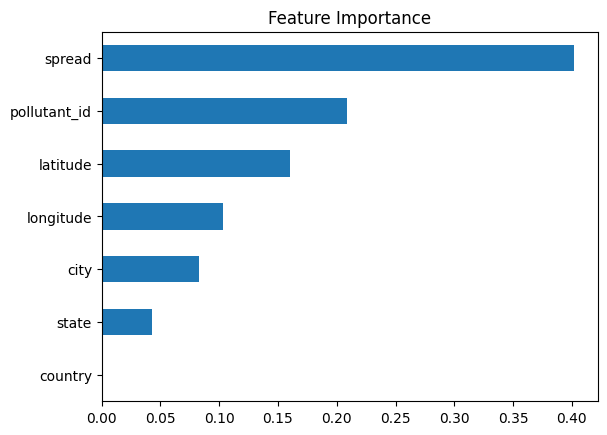

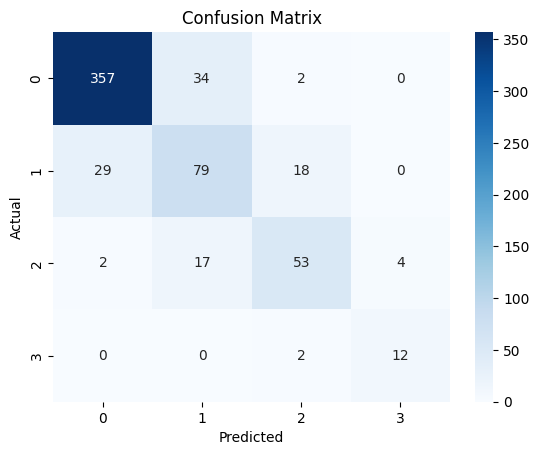

In [19]:
#visualisations based on the model results
import matplotlib.pyplot as plt
feature_importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()